In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_excel("student_cleaned_data.xlsx")
df.head()

,Timestamp,Name,Age,Gender,Branch,Semester,Study Hours per Day,Attendance Percentage,Internal Marks (Out of 30),Assignment Completion Rate (%),Participation in Extra Activities,Sleep Hours per Day,Internet Usage (Hours per Day),Do You Attend Coaching Classes?,Final Exam Result (%)
0,2026-04-25 12:09:56.799,Naruto Uzumaki,21,Male,ENTC,1.0,1,45,4,17,Yes,3,1.0,Yes,100
1,2026-04-25 12:13:26.147,Yoriichi tsunukami,14,Male,Computer,4.0,2,100,30,100,Yes,4,0.0,No,100
2,2026-04-25 12:23:32.665,Remedy Alexander,17,Female,Computer,4.0,6,36,26,17,Yes,15,1.0,No,16
3,2026-04-25 12:33:19.452,Priya Sharma,20,Female,Computer,4.0,6,83,26,83,Yes,7,2.0,Yes,82
4,2026-04-25 12:34:19.583,Rohan Mehta,21,Male,ENTC,5.0,3,78,22,72,No,5,3.0,Yes,72


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Timestamp                          8 non-null      datetime64[ns]
 1   Name                               8 non-null      object        
 2   Age                                8 non-null      int64         
 3   Gender                             8 non-null      object        
 4   Branch                             8 non-null      object        
 5   Semester                           8 non-null      float64       
 6   Study Hours per Day                8 non-null      int64         
 7   Attendance Percentage              8 non-null      int64         
 8   Internal Marks (Out of 30)         8 non-null      int64         
 9   Assignment Completion Rate (%)     8 non-null      int64         
 10  Participation in Extra Activities  8 non-n

In [15]:
df.describe()

,Timestamp,Age,Semester,Study Hours per Day,Attendance Percentage,Internal Marks (Out of 30),Assignment Completion Rate (%),Sleep Hours per Day,Internet Usage (Hours per Day),Final Exam Result (%)
count,8,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,7.000000,8.000000
mean,2026-04-25 12:29:02.229000192,19.000000,3.857143,4.250000,67.875000,23.375000,60.750000,6.50000,2.857143,72.250000
min,2026-04-25 12:09:56.799000,14.000000,1.000000,1.000000,36.000000,4.000000,17.000000,3.00000,0.000000,16.000000
25%,2026-04-25 12:21:01.035500032,16.250000,3.642857,2.750000,53.250000,25.000000,50.750000,4.75000,1.000000,70.000000
50%,2026-04-25 12:33:49.517500160,20.500000,4.000000,4.500000,72.500000,26.000000,67.000000,5.50000,2.000000,72.000000
75%,2026-04-25 12:36:45.796749824,21.000000,4.250000,6.000000,79.250000,26.250000,75.500000,7.00000,4.500000,86.500000
max,2026-04-25 12:43:38.585000,24.000000,6.000000,7.000000,100.000000,30.000000,100.000000,15.00000,7.000000,100.000000
std,NaN,3.625308,1.456863,2.251983,20.999575,8.122939,29.625038,3.70328,2.672612,26.369625


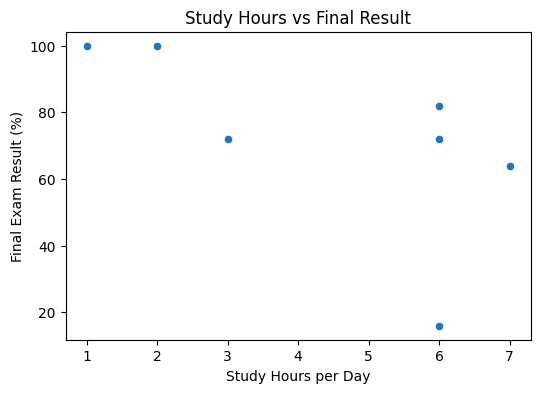

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Study Hours per Day', y='Final Exam Result (%)', data=df)
plt.title("Study Hours vs Final Result")
plt.show()

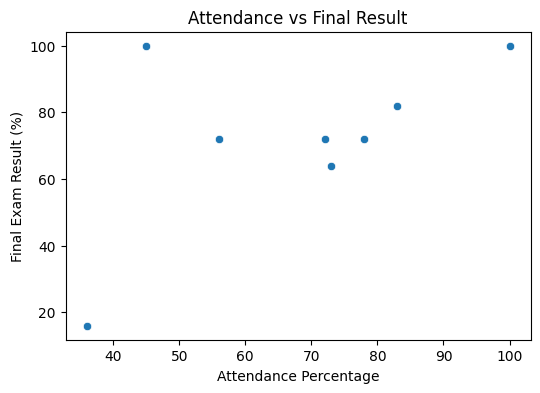

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Attendance Percentage', y='Final Exam Result (%)', data=df)
plt.title("Attendance vs Final Result")
plt.show()

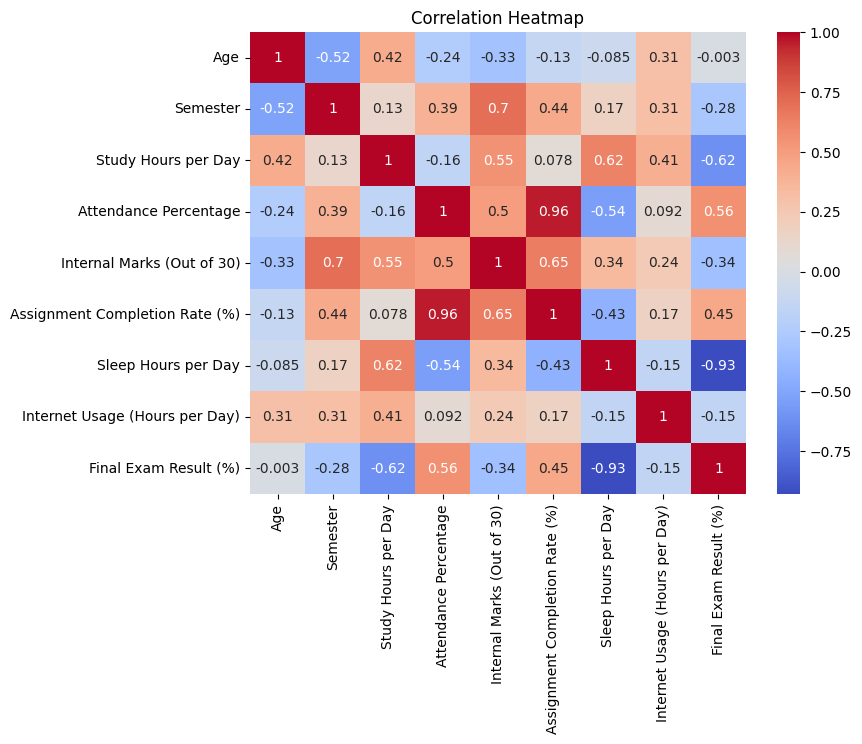

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
X = df[['Study Hours per Day',
        'Attendance Percentage',
        'Internal Marks (Out of 30)',
        'Assignment Completion Rate (%)']]

y = df['Final Exam Result (%)']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 9.48325458004902
R2 Score: 0.5703771950385843
